In [27]:
import pandas as pd
import numpy as np
from joblib import load
import warnings
from geopy.distance import geodesic
from scipy.interpolate import RegularGridInterpolator,NearestNDInterpolator
from datetime import datetime, timedelta,timezone
from scipy.io import netcdf
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import os
import xarray as xr
import math
import folium
import pstats
import cProfile
KNOTS_TO_KM_PER_H = 1.852
HOURS_IN_DAY = 24
MINUTES_IN_HOUR = 60
import matplotlib.pyplot as plt
import pickle

In [28]:
n_trip = 22 #22 84 61 70
mode = 'hc'

with open(f"{mode}_corrected_bayesopt_results_trip_{n_trip}.pkl", "rb") as f:
        corrected_inverted = pickle.load(f)


In [29]:
# Scores and Optimization
Mean_of_mean_scores = corrected_inverted.get("Mean_of_mean_scores")
u_opt_bayes_dp = corrected_inverted.get("U_opt_EP")

# ETA and Fuel Data
ETA = corrected_inverted.get("ETA")
t_Sail_DPITR = corrected_inverted.get("ETA_DP")
t_Sail_mbayes_dp = corrected_inverted.get("ETA_BAYES_EP")
Old_Fuel = corrected_inverted.get("Measured_Fuel")
New_Fuel_DPITR = corrected_inverted.get("DP_Fuel")
New_Fuel_mbayes_dp = corrected_inverted.get("DP+Bayes_EP_Fuel")

# Emissions
Emissions_Measured = corrected_inverted.get("Emissions_Measured")
Emissions_DP = corrected_inverted.get("Emissions_DP")
Emissions_DP_BAYES_EP = corrected_inverted.get("Emissions_DP_BAYES_EP")

# Fuel Change and Arrival Rates
Fuel_Change_DP = corrected_inverted.get("%_Fuel_Change_DP")
Fuel_Change_DP_Bayes_EP = corrected_inverted.get("%_Fuel_Change_DP+Bayes_EP")
Relative_Error_mbayes_dp = corrected_inverted.get("%_Late_Arrival_DP+Bayes_EP")

# Voyage and Measurement Data
Voy_opt_DPITR = corrected_inverted.get("Voy_opt_DPITR")
out_Voy_opt_mbayes_dp = corrected_inverted.get("Voy_opt_mbayes_dp")
data_example = corrected_inverted.get("Measurement")

print(f"Successfully loaded data for trip {n_trip}")

Successfully loaded data for trip 22


In [30]:
# 1. Print Time and Fuel Metrics
print("--- Voyage Performance Summary ---")
print(f"ETA (DPITR):         {t_Sail_DPITR}")
print(f"ETA (Bayes EP):      {t_Sail_mbayes_dp}")
print(f"Measured Fuel:       {Old_Fuel:.2f}")
print(f"DP Fuel:             {New_Fuel_DPITR:.2f}")
print(f"DP+Bayes EP Fuel:    {New_Fuel_mbayes_dp:.2f}")

# 2. Print Emissions Data
print("\n--- Emissions (CO2) ---")
print(f"Measured Emissions:  {Emissions_Measured:.2f}")
print(f"DP Emissions:        {Emissions_DP:.2f}")
print(f"Bayes EP Emissions:  {Emissions_DP_BAYES_EP:.2f}")

# 3. Print Change Percentages and Errors
print("\n--- Comparison Metrics ---")
print(f"Fuel Change (DP):          {Fuel_Change_DP:.2f}%")
print(f"Fuel Change (Bayes EP):    {Fuel_Change_DP_Bayes_EP:.2f}%")
print(f"Late Arrival Rate (Bayes): {Relative_Error_mbayes_dp:.2f}%")

--- Voyage Performance Summary ---
ETA (DPITR):         142.54023097712957
ETA (Bayes EP):      143.24
Measured Fuel:       121.62
DP Fuel:             113.99
DP+Bayes EP Fuel:    112.74

--- Emissions (CO2) ---
Measured Emissions:  378.72
DP Emissions:        354.95
Bayes EP Emissions:  351.08

--- Comparison Metrics ---
Fuel Change (DP):          -6.27%
Fuel Change (Bayes EP):    -7.30%
Late Arrival Rate (Bayes): 1.30%


In [31]:
data_example['Cumulative Distance'].iloc[-1]

np.float64(3286.90099990256)

In [32]:
def plot_all_with_segmentation_new(Data_const, Data_comp, cluster_assignment, n_trip=""):
    unique_clusters = np.unique(cluster_assignment)
    colors = plt.cm.get_cmap('Paired', len(unique_clusters))
    color_dict = {cluster: colors(i) for i, cluster in enumerate(unique_clusters)}

    # Create the figure and axes with a GridSpec layout
    fig = plt.figure(figsize=(30, 12))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1])

    # Create subplots for the first row, spanning two columns for each plot
    ax_peng = fig.add_subplot(gs[0, :2])  # P_eng spans the first two columns
    ax_vg = fig.add_subplot(gs[0, 2])  # V_g takes the third column

    # Create subplots for the second row (three plots)
    ax_wave = fig.add_subplot(gs[1, 0])
    ax_current = fig.add_subplot(gs[1, 1])
    ax_wind = fig.add_subplot(gs[1, 2])

    # First Row: V_g (Speed)
    sailed_distance = Data_const['Cumulative Distance'] / Data_const['Cumulative Distance'].iloc[-1] * len(Data_const)
    speed = Data_const['V_G (s)']
    power = Data_const['P_eng (s)']
    sailed_distance_c = Data_comp['Cumulative Distance'] / Data_const['Cumulative Distance'].iloc[-1] * len(Data_const)
    speed_c = Data_comp['V_G (s)']
    power_c = Data_comp['P_eng (s)']

    ax_vg.plot(sailed_distance_c, speed_c, color='gray', linestyle='--', linewidth=3, label='Measurement')
    ax_vg.plot(sailed_distance, speed, color='black', linestyle='-', linewidth=3, label='Optimisation')
    ax_vg.set_xlabel('Waypoints', fontsize=36)
    ax_vg.set_ylabel('$V$ (kn)', fontsize=36)
    ax_vg.set_ylim(9, 16)  # --- ADDED Y-LIMIT ---
    ax_vg.tick_params(axis='both', labelsize=30)  # Set tick label size
    ax_vg.grid()

    # Cluster shading for V_g
    previous_cluster = cluster_assignment[0]
    start_idx = 0
    for j in range(1, len(cluster_assignment)):
        if cluster_assignment[j] != previous_cluster:
            ax_vg.axvline(x=sailed_distance.iloc[j], color='k', linestyle='--', linewidth=0.8)
            ax_vg.axvspan(sailed_distance.iloc[start_idx], sailed_distance.iloc[j], 
                          color=color_dict[previous_cluster], alpha=0.5)
            previous_cluster = cluster_assignment[j]
            start_idx = j
    ax_vg.axvspan(sailed_distance.iloc[start_idx], sailed_distance.iloc[-1], 
                  color=color_dict[previous_cluster], alpha=0.5)
    ax_vg.legend(['Measurement','Optimisation'],fontsize=20)
    
    # First Row: P_eng (Engine Power)
    ax_peng.plot(sailed_distance_c, power_c, color='gray', linestyle='--', linewidth=3, label='Measurement')
    ax_peng.plot(sailed_distance, power, color='black', linestyle='-', linewidth=3, label='Optimisation')
    ax_peng.set_xlabel('Waypoints', fontsize=36)
    ax_peng.set_ylabel('$P$ (kW)', fontsize=36)
    ax_peng.set_ylim(1000, 4500)  # --- ADDED Y-LIMIT ---
    ax_peng.tick_params(axis='both', labelsize=30)  # Set tick label size
    ax_peng.grid()

    # Cluster shading for P_eng
    previous_cluster = cluster_assignment[0]
    start_idx = 0
    for j in range(1, len(cluster_assignment)):
        if cluster_assignment[j] != previous_cluster:
            ax_peng.axvline(x=sailed_distance.iloc[j], color='k', linestyle='--', linewidth=0.8)
            ax_peng.axvspan(sailed_distance.iloc[start_idx], sailed_distance.iloc[j], 
                            color=color_dict[previous_cluster], alpha=0.5)
            previous_cluster = cluster_assignment[j]
            start_idx = j
    ax_peng.axvspan(sailed_distance.iloc[start_idx], sailed_distance.iloc[-1], 
                    color=color_dict[previous_cluster], alpha=0.5)
    ax_peng.legend(['Measurement','Optimisation'],fontsize=20)
    
    # Second Row: Wave Height and Direction
    swh_hindcast = Data_const['swh_hindcast']
    wave_direction = Data_const['wave_dir_hindcast_head']
    ax_wave.plot(sailed_distance, swh_hindcast, color='blue', linestyle='-', linewidth=3)
    
    ax_wave.set_ylim(0, 4)  # --- ADDED Y-LIMIT ---
    ax_wave_dir = ax_wave.twinx()
    ax_wave_dir.plot(sailed_distance, wave_direction, color='green', linestyle='--', linewidth=2)
    
    ax_wave_dir.set_ylim(0, 180)  # --- ADDED Y-LIMIT ---
    ax_wave_dir.set_yticks([0, 45, 90, 135, 180])  # --- ADDED Y-TICKS ---

    ax_wave.set_xlabel('Waypoints', fontsize=36)
    ax_wave.set_ylabel('$H_{s}$ (m)', fontsize=36, color='blue')
    ax_wave.tick_params(axis='x', labelsize=30)  # Set x-tick label size
    ax_wave.tick_params(axis='y', colors='blue', labelsize=30)
    ax_wave_dir.set_ylabel('$\\alpha_{Hs}$ (°)', fontsize=36, color='green')
    ax_wave_dir.tick_params(axis='y', colors='green', labelsize=30)
    ax_wave.grid()

    # Cluster shading for Wave Height
    previous_cluster = cluster_assignment[0]
    start_idx = 0
    for j in range(1, len(cluster_assignment)):
        if cluster_assignment[j] != previous_cluster:
            ax_wave.axvline(x=sailed_distance.iloc[j], color='k', linestyle='--', linewidth=0.8)
            ax_wave.axvspan(sailed_distance.iloc[start_idx], sailed_distance.iloc[j], 
                            color=color_dict[previous_cluster], alpha=0.5)
            previous_cluster = cluster_assignment[j]
            start_idx = j
    ax_wave.axvspan(sailed_distance.iloc[start_idx], sailed_distance.iloc[-1], 
                    color=color_dict[previous_cluster], alpha=0.5)

    # Second Row: Sea Current Speed and Direction
    sea_current_speed = Data_const['current_speed']
    sea_current_direction = Data_const['angle_current_head']
    ax_current.plot(sailed_distance, sea_current_speed, color='blue', linestyle='-', linewidth=3)
    
    ax_current.set_ylim(0, 2)  # --- ADDED Y-LIMIT ---
    ax_current_dir = ax_current.twinx()
    ax_current_dir.plot(sailed_distance, sea_current_direction, color='green', linestyle='--', linewidth=2)
    
    ax_current_dir.set_ylim(0, 180)  # --- ADDED Y-LIMIT ---
    ax_current_dir.set_yticks([0, 45, 90, 135, 180])  # --- ADDED Y-TICKS ---

    ax_current.set_xlabel('Waypoints', fontsize=36)
    ax_current.set_ylabel('$V_{current}$ (m/s)', fontsize=36, color='blue')
    ax_current.tick_params(axis='x', labelsize=30)  # Set x-tick label size
    ax_current.tick_params(axis='y', colors='blue', labelsize=30)
    ax_current_dir.set_ylabel('$\\alpha_{current}$ (°)', fontsize=36, color='green')
    ax_current_dir.tick_params(axis='y', colors='green', labelsize=30)
    ax_current.grid()

    # Cluster shading for Sea Current Speed
    previous_cluster = cluster_assignment[0]
    start_idx = 0
    for j in range(1, len(cluster_assignment)):
        if cluster_assignment[j] != previous_cluster:
            ax_current.axvline(x=sailed_distance.iloc[j], color='k', linestyle='--', linewidth=0.8)
            ax_current.axvspan(sailed_distance.iloc[start_idx], sailed_distance.iloc[j], 
                               color=color_dict[previous_cluster], alpha=0.5)
            previous_cluster = cluster_assignment[j]
            start_idx = j
    ax_current.axvspan(sailed_distance.iloc[start_idx], sailed_distance.iloc[-1], 
                       color=color_dict[previous_cluster], alpha=0.5)

    # Second Row: Wind Speed and Direction
    wind_speed_hindcast = Data_const['wind_speed_hindcast']
    wind_direction = Data_const['wind_dir_hindcast_head']
    ax_wind.plot(sailed_distance, wind_speed_hindcast, color='blue', linestyle='-', linewidth=3)
    
    ax_wind.set_ylim(0, 15)  # --- ADDED Y-LIMIT ---
    ax_wind_dir = ax_wind.twinx()
    ax_wind_dir.plot(sailed_distance, wind_direction, color='green', linestyle='--', linewidth=2)
    
    ax_wind_dir.set_ylim(0, 180)  # --- ADDED Y-LIMIT ---
    ax_wind_dir.set_yticks([0, 45, 90, 135, 180])  # --- ADDED Y-TICKS ---

    ax_wind.set_xlabel('Waypoints', fontsize=36)
    ax_wind.set_ylabel('$V_{wind}$ (m/s)', fontsize=36, color='blue')
    ax_wind.tick_params(axis='x', labelsize=30)  # Set x-tick label size
    ax_wind.tick_params(axis='y', colors='blue', labelsize=30)
    ax_wind_dir.set_ylabel('$\\alpha_{wind}$ (°)', fontsize=36, color='green')
    ax_wind_dir.tick_params(axis='y', colors='green', labelsize=30)
    ax_wind.grid()

    # Cluster shading for Wind Speed
    previous_cluster = cluster_assignment[0]
    start_idx = 0
    for j in range(1, len(cluster_assignment)):
        if cluster_assignment[j] != previous_cluster:
            ax_wind.axvline(x=sailed_distance.iloc[j], color='k', linestyle='--', linewidth=0.8)
            ax_wind.axvspan(sailed_distance.iloc[start_idx], sailed_distance.iloc[j], 
                            color=color_dict[previous_cluster], alpha=0.5)
            previous_cluster = cluster_assignment[j]
            start_idx = j
    ax_wind.axvspan(sailed_distance.iloc[start_idx], sailed_distance.iloc[-1], 
                    color=color_dict[previous_cluster], alpha=0.5)

    plt.tight_layout(pad=1)
    fmt='png'
    plt.savefig(f'power optimal {n_trip}.'+fmt, format=fmt, bbox_inches='tight', pad_inches=0,dpi=500)
    plt.show()

C:\Users\danver\AppData\Local\Temp\ipykernel_13976\3162955799.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Paired', len(unique_clusters))


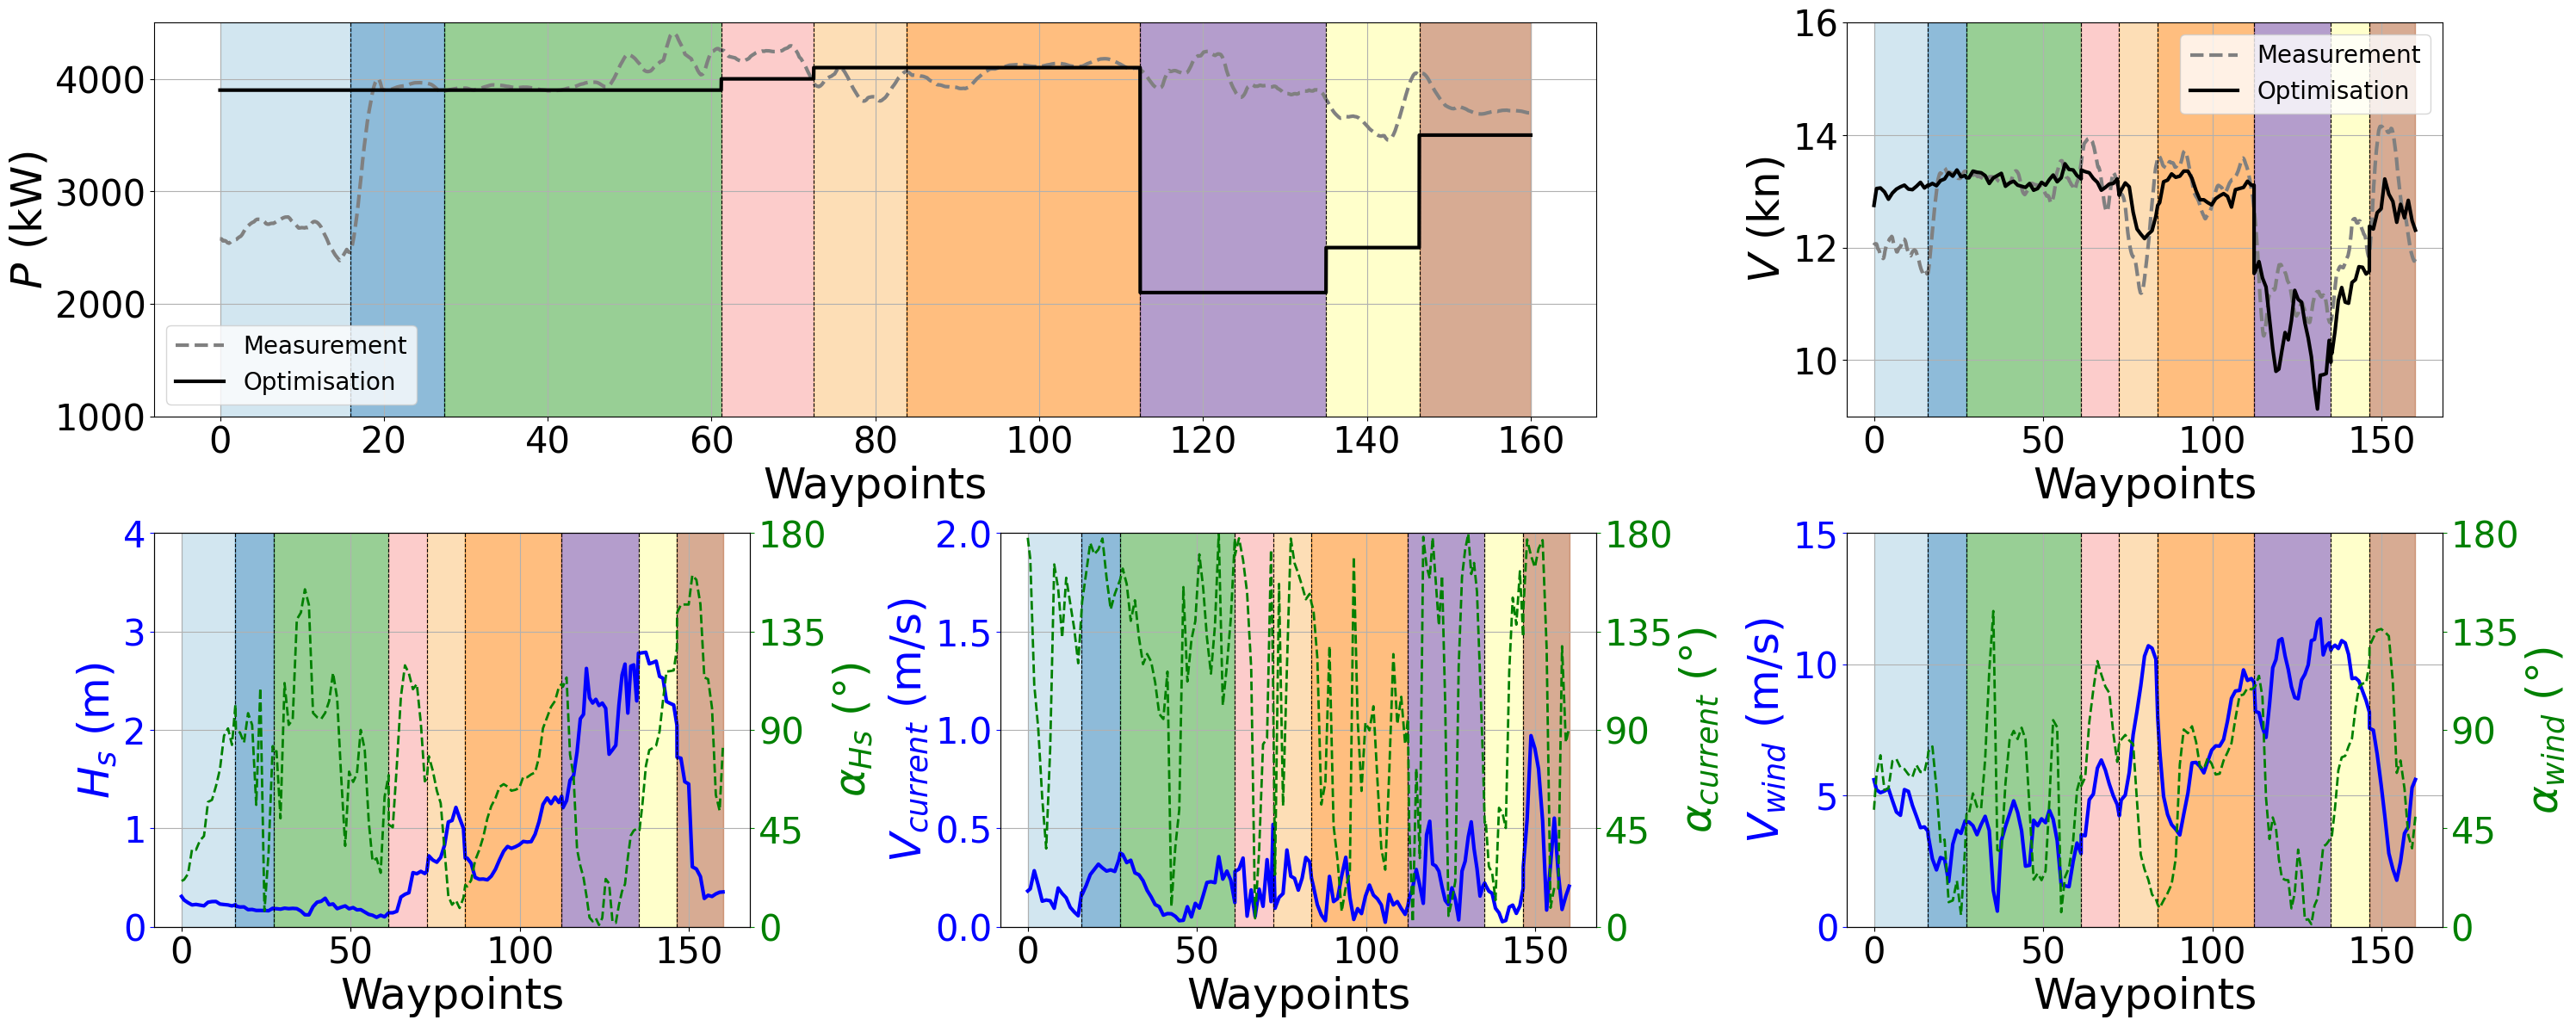

In [33]:
plot_all_with_segmentation_new(Voy_opt_DPITR,data_example, Voy_opt_DPITR['Leg'].values)

In [34]:
def plot_map_with_clusters(Nominal_Trips, cluster_assignment):

    unique_clusters = np.unique(cluster_assignment)
    colors = plt.cm.get_cmap('Paired', len(unique_clusters))
    color_dict = {cluster: colors(i) for i, cluster in enumerate(unique_clusters)}
    fig = plt.figure(figsize=(12, 3))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    Voyage = Nominal_Trips
    longitudes = Voyage['lon']
    latitudes = Voyage['lat']
    lon_min, lon_max = longitudes.min() - 1, longitudes.max() + 1
    lat_min, lat_max = latitudes.min() - 1, latitudes.max() + 1
    
    ax.add_feature(cfeature.LAND, edgecolor='black')
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    
    ax.plot(Voyage['lon'], Voyage['lat'], color='black', linewidth=1.0, transform=ccrs.PlateCarree())

    previous_cluster = cluster_assignment[0]
    start_idx = 0

    for j in range(1, len(cluster_assignment)):
        if cluster_assignment[j] != previous_cluster:
            ax.plot(Voyage['lon'].iloc[start_idx:j+1], Voyage['lat'].iloc[start_idx:j+1], 
                    color=color_dict[previous_cluster], linewidth=5, transform=ccrs.PlateCarree())
            ax.plot(Voyage['lon'].iloc[j], Voyage['lat'].iloc[j],marker='|', color='blue', markersize=45, markeredgewidth=3)

            previous_cluster = cluster_assignment[j]
            start_idx = j

    ax.plot(Voyage['lon'].iloc[start_idx:], Voyage['lat'].iloc[start_idx:], 
            color=color_dict[previous_cluster], linewidth=5, transform=ccrs.PlateCarree())
    
    departure_marker = ax.plot(longitudes.iloc[0], latitudes.iloc[0], marker='D', color='green', markersize=10, label='Departure')
    destination_marker = ax.plot(longitudes.iloc[-1], latitudes.iloc[-1], marker='D', color='red', markersize=10, label='Destination')
    ax.text(longitudes.iloc[0]-2, latitudes.iloc[0]-1, 'Departure', color='green', fontsize=16, weight='bold', transform=ccrs.PlateCarree(), ha='left', va='bottom', bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))
    ax.text(longitudes.iloc[-1]-1 , latitudes.iloc[-1]-2, 'Destination', color='red', fontsize=16, weight='bold', transform=ccrs.PlateCarree(), ha='left', va='bottom', bbox=dict(facecolor='white', alpha=0.75, edgecolor='none'))
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.set_aspect('auto')
    plt.tight_layout(pad=1.0)
    fmt='png'
    plt.savefig(f'pelt map {n_trip}.'+fmt, format=fmt, bbox_inches='tight', pad_inches=0,dpi=500)
    plt.show()


In [35]:
import cartopy.crs as ccrs  # Import Cartopy
import cartopy.feature as cfeature
import cartopy

C:\Users\danver\AppData\Local\Temp\ipykernel_13976\1939009705.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Paired', len(unique_clusters))


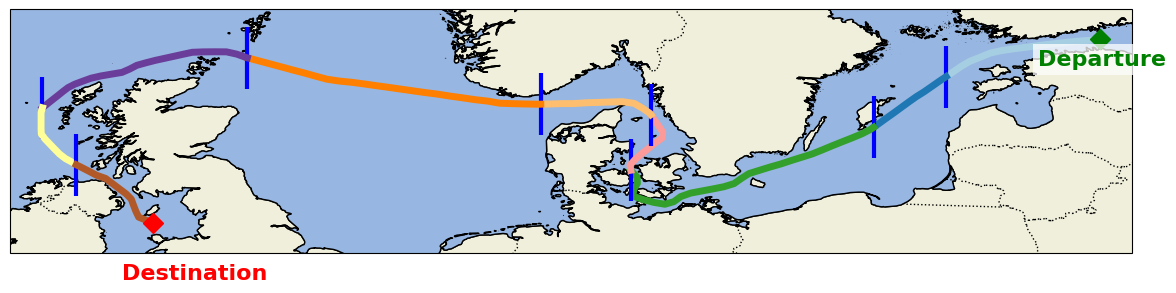

In [36]:
plot_map_with_clusters(out_Voy_opt_mbayes_dp,  out_Voy_opt_mbayes_dp['Leg'].values)

In [37]:
N_legs = len(u_opt_bayes_dp['params'])

In [38]:
FFUEL = ['V_G (s)',
         'P_eng (s)',
         'N_eng (S)',
         'T_mean (S)',
         'swh_hindcast', 
         'wave_dir_hindcast_head', 
         'wave_period_hindcast', 
         'wind_speed_hindcast', 
         'wind_dir_hindcast_head',
         'current_speed',
         'angle_current_head']

In [39]:
def generate_enhanced_visualization(data_signal_1, data_signal_2, data_signal_3, cluster_assignment, cluster_colors=None,
                                    var_distance='Cumulative Distance', var_power='P_eng (s)', var_speed='V_G (s)',
                                    var_swh_hindcast='swh_hindcast', var_wave_angle='wave_dir_hindcast_head',
                                    var_current_speed='current_speed', var_current_angle='angle_current_head',
                                    var_wind_speed='wind_speed_hindcast', var_wind_angle='wind_dir_hindcast_head',
                                    vertical_width_factor=1.5, label_size=24, tick_size=20, title_size=30):
    """
    Generates a multi-panel visualization comparing three datasets for power, speed, and environmental conditions.
    """

    # Extract values from the dataframes
    distance_1 = data_signal_1[var_distance]
    distance_2 = data_signal_2[var_distance]  # Used as reference for shading
    distance_3 = data_signal_3[var_distance]

    power_1, power_2, power_3 = data_signal_1[var_power], data_signal_2[var_power], data_signal_3[var_power]
    speed_1, speed_2, speed_3 = data_signal_1[var_speed], data_signal_2[var_speed], data_signal_3[var_speed]

    swh_hindcast = data_signal_3[var_swh_hindcast]
    wave_angle = data_signal_3[var_wave_angle]

    current_speed = data_signal_3[var_current_speed]
    current_angle = data_signal_3[var_current_angle]

    wind_speed_hindcast = data_signal_3[var_wind_speed]
    wind_angle = data_signal_3[var_wind_angle]

    # Create figure and grid layout
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, width_ratios=[3, vertical_width_factor], height_ratios=[1, 1], wspace=0.3, hspace=0.3)

    # Large horizontal plots
    axA = fig.add_subplot(gs[0, 0],sharex=None)
    axB = fig.add_subplot(gs[1, 0],sharex=axA)

    # Create a separate vertical grid for C, D, and E
    gs_right = gs[:, 1].subgridspec(3, 1, hspace=0.4)
    axC = fig.add_subplot(gs_right[0, 0],sharex=None)
    axD = fig.add_subplot(gs_right[1, 0],sharex=axC)
    axE = fig.add_subplot(gs_right[2, 0],sharex=axC)

    # Set default cluster colors if not provided
    if cluster_colors is None:
        unique_clusters = np.unique(cluster_assignment)
        colors = plt.cm.get_cmap('Paired', len(unique_clusters))
        cluster_colors = {cluster: colors(i) for i, cluster in enumerate(unique_clusters)}

    # --- Plot A: Power ---
    axA.plot(distance_1, power_1, label="Measurement", color='black', linewidth=2)
    axA.plot(distance_2, power_2, label="DP", color='red', linestyle="--", linewidth=2)
    axA.plot(distance_3, power_3, label="DP+Bayes", color='blue', linestyle="-.", linewidth=2)
    axA.set_title("A: Engine Power", fontsize=title_size)
    axA.set_ylabel("Power (kW)", fontsize=label_size)
    axA.tick_params(axis='both', labelsize=tick_size)
    axA.grid()
    axA.set_ylim(2000, 4500)
    axA.set_yticks([2000,2500,3000,3500,4000,4500])

    # --- Plot B: Speed with 2 additional signals and mean lines ---
    axB.plot(distance_1, speed_1, label="Measurement", color='black', linewidth=2)
    axB.plot(distance_2, speed_2, label="DP", color='red', linestyle="--", linewidth=2)
    axB.plot(distance_3, speed_3, label="DP+Bayes", color='blue', linestyle="-.", linewidth=2)
    
    # Calculate and plot mean values
    axB.axhline(np.mean(speed_1), color='black', linewidth=1, label="Mean Speed 1")
    axB.axhline(np.mean(speed_2), color='red', linewidth=1, label="Mean Speed 2")
    axB.axhline(np.mean(speed_3), color='blue', linewidth=1, label="Mean Speed 3")
    axB.grid()
    axB.set_title("B: Speed Over Ground", fontsize=title_size)
    axB.set_ylabel("Speed (kn)", fontsize=label_size)
    axB.tick_params(axis='both', labelsize=tick_size)
    axB.set_ylim(9, 16)
    axB.set_yticks([9,10,11,12,13,14,15,16])

    # --- Cluster Shading Logic ---
    previous_cluster = cluster_assignment[0]
    start_idx = 0
    for j in range(1, len(cluster_assignment)):
        if cluster_assignment[j] != previous_cluster:
            for ax in [axA, axB, axC, axD, axE]:  
                ax.axvline(x=distance_2.iloc[j], color='k', linestyle='--', linewidth=0.8)
                ax.axvspan(distance_2.iloc[start_idx], distance_2.iloc[j], 
                           color=cluster_colors[previous_cluster], alpha=0.4)
            previous_cluster = cluster_assignment[j]
            start_idx = j
    for ax in [axA, axB, axC, axD, axE]:  
        ax.axvspan(distance_2.iloc[start_idx], distance_2.iloc[-1], 
                   color=cluster_colors[previous_cluster], alpha=0.4)

    # --- Environmental Plots ---
    def plot_environment(ax, ax_dir, x, y1, y2, y1_label, y2_label, title, color1='blue', color2='purple'):
        ax.plot(x, y1, color=color1, linestyle='-', linewidth=3, label=y1_label)
        ax_dir.plot(x, y2, color=color2, linestyle='--', linewidth=2, alpha=0.75)
        
        # Axis locking for the twinx (angles)
        ax_dir.set_ylim(0, 180)
        ax_dir.set_yticks([0, 45, 90, 135, 180])

        ax.set_title(title, fontsize=title_size)
        ax.set_ylabel(y1_label, fontsize=label_size, color=color1)
        ax_dir.set_ylabel(y2_label, fontsize=label_size, color=color2)
        ax.tick_params(axis='y', colors=color1, labelsize=tick_size)
        ax.tick_params(axis='x', labelsize=tick_size)
        ax_dir.tick_params(axis='y', colors=color2, labelsize=tick_size)
        ax.grid()

    # Call plotting function and enforce left y-axis limits
    plot_environment(axC, axC.twinx(), distance_3, swh_hindcast, wave_angle, "$H_s$ (m)", "$\\alpha_{Hs}$ (°)", "C: Wave Height")
    axC.set_ylim(0, 4)

    plot_environment(axD, axD.twinx(), distance_3, current_speed, current_angle, "$V_{current}$ (m/s)", "$\\alpha_{current}$ (°)", "D: Current Speed")
    axD.set_ylim(0, 2)

    plot_environment(axE, axE.twinx(), distance_3, wind_speed_hindcast, wind_angle, "$V_{wind}$ (m/s)", "$\\alpha_{wind}$ (°)", "E: Wind Speed")
    axE.set_ylim(0, 15)

    axE.set_xlabel("Sailed distance (km)", fontsize=label_size)
    axB.set_xlabel("Sailed distance (km)", fontsize=label_size)
    fig.legend(["Measurement", "DP", "BO+EP"], loc='lower center', bbox_to_anchor=(0.5, -0.025), 
               ncol=3, fontsize=label_size-6, framealpha=0.5)

    plt.tight_layout()
    plt.show()

In [40]:
def generate_cluster_colors(x10, cmap_name='Blues'):
    """
    Generates a dictionary mapping clusters to colors based on x10 values.

    Parameters:
    - x10: Array of numerical values influencing color intensity.
    - cmap_name: Matplotlib colormap name.

    Returns:
    - cluster_colors: Dictionary mapping cluster indices to colors.
    """
    # Normalize x10 to 0-1 range
    x10_norm = 1-(x10 - np.min(x10)) / (np.max(x10) - np.min(x10))
    
    # Generate colors based on colormap
    cmap = plt.get_cmap(cmap_name)
    cluster_colors = {i+1: cmap(value) for i, value in enumerate(x10_norm)}
    
    return cluster_colors

In [41]:
cluster_colors = generate_cluster_colors(Mean_of_mean_scores.values)

In [42]:
cluster_colors

{1: (np.float64(0.4666666666666667),
  np.float64(0.7081891580161477),
  np.float64(0.8493656286043829),
  np.float64(1.0)),
 2: (np.float64(0.2909803921568628),
  np.float64(0.5945098039215686),
  np.float64(0.7890196078431373),
  np.float64(1.0)),
 3: (np.float64(0.6047058823529413),
  np.float64(0.7839753940792004),
  np.float64(0.8791387927720108),
  np.float64(1.0)),
 4: (np.float64(0.3061130334486736),
  np.float64(0.6048442906574394),
  np.float64(0.7949250288350634),
  np.float64(1.0)),
 5: (np.float64(0.7845905420991927),
  np.float64(0.864236831987697),
  np.float64(0.9399615532487505),
  np.float64(1.0)),
 6: (np.float64(0.3969088811995388),
  np.float64(0.6668512110726644),
  np.float64(0.8303575547866207),
  np.float64(1.0)),
 7: (np.float64(0.9686274509803922),
  np.float64(0.984313725490196),
  np.float64(1.0),
  np.float64(1.0)),
 8: (np.float64(0.7845905420991927),
  np.float64(0.864236831987697),
  np.float64(0.9399615532487505),
  np.float64(1.0)),
 9: (np.float64(0.

In [43]:
from sklearn.preprocessing import MinMaxScaler

C:\Users\danver\AppData\Local\Temp\ipykernel_13976\4075469129.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


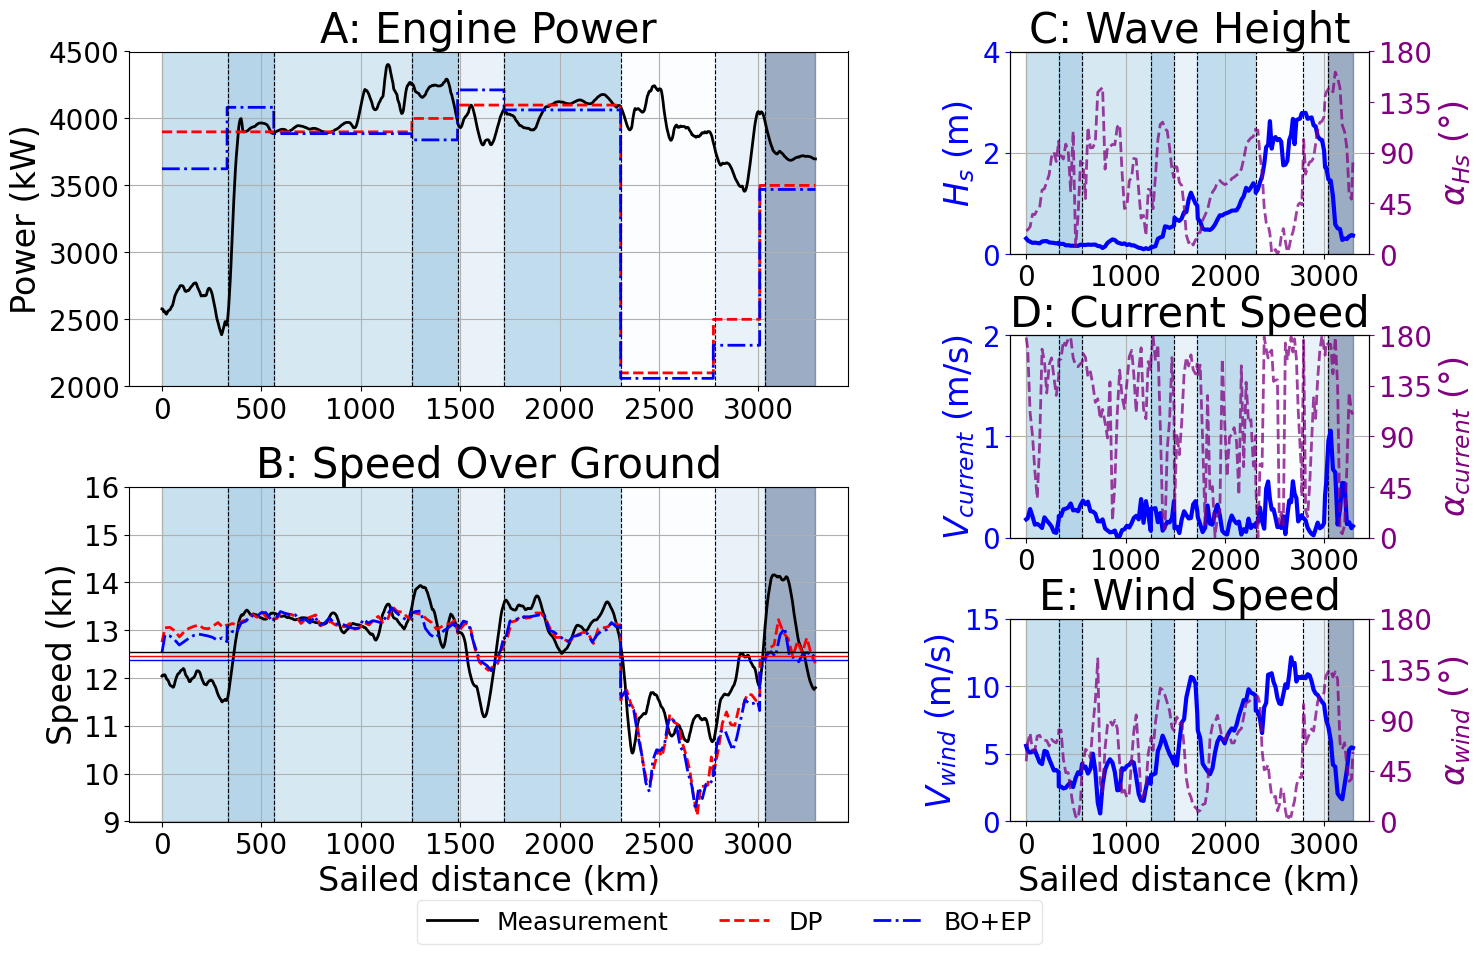

In [44]:
generate_enhanced_visualization(data_example, Voy_opt_DPITR, out_Voy_opt_mbayes_dp, out_Voy_opt_mbayes_dp['Leg'].values,cluster_colors = cluster_colors)

In [47]:
def plot_metocean_conditions(data, 
                             var_distance='Cumulative Distance',
                             var_swh_hindcast='swh_hindcast', 
                             var_wave_angle='wave_dir_hindcast_head',
                             var_current_speed='current_speed', 
                             var_current_angle='angle_current_head',
                             var_wind_speed='wind_speed_hindcast', 
                             var_wind_angle='wind_dir_hindcast_head',
                             label_size=36, tick_size=32, title_size=40):
    """
    Generates a 1x3 visualization of metocean conditions (Waves, Current, Wind).
    The plot features a white background and ignores cluster/leg shading logic.
    """
    
    # Extract data from the provided DataFrame
    x = data[var_distance]
    
    # 1. Setup the figure: 1 row, 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(24, 6), facecolor='white')
    
    # Helper function to handle twinx and consistent styling
    def draw_env_panel(ax, x_data, y_primary, y_secondary, 
                       y_p_label, y_s_label, title, 
                       p_ylim, color_p='blue', color_s='purple'):
        
        ax_right = ax.twinx()
        
        # Primary axis (Magnitudes: Height or Speed)
        ax.plot(x_data, y_primary, color=color_p, linestyle='-', linewidth=3)
        ax.set_ylabel(y_p_label, fontsize=label_size, color=color_p)
        ax.tick_params(axis='y', colors=color_p, labelsize=tick_size)
        ax.set_ylim(p_ylim)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Secondary axis (Angles)
        ax_right.plot(x_data, y_secondary, color=color_s, linestyle='--', linewidth=2, alpha=0.7)
        ax_right.set_ylabel(y_s_label, fontsize=label_size, color=color_s)
        ax_right.tick_params(axis='y', colors=color_s, labelsize=tick_size)
        ax_right.set_ylim(0, 180)
        ax_right.set_yticks([0, 45, 90, 135, 180])
        
        # General formatting
        ax.set_title(title, fontsize=title_size, pad=20)
        ax.set_xlabel("Sailed distance (km)", fontsize=label_size)
        ax.tick_params(axis='x', labelsize=tick_size)
        ax.set_facecolor('white')

    # --- Plot 1: Wave Height and Direction ---
    draw_env_panel(
        axes[0], x, data[var_swh_hindcast], data[var_wave_angle],
        "$H_s$ (m)", "$\\alpha_{Hs} (^{\\circ})$", "Waves", (0, 4)
    )

    # --- Plot 2: Current Speed and Direction ---
    draw_env_panel(
        axes[1], x, data[var_current_speed], data[var_current_angle],
        "$V_{current}$ (m/s)", "$\\alpha_{current} (^{\\circ})$", "Currents", (0, 2)
    )

    # --- Plot 3: Wind Speed and Direction ---
    draw_env_panel(
        axes[2], x, data[var_wind_speed], data[var_wind_angle],
        "$V_{wind}$ (m/s)", "$\\alpha_{wind} (^{\\circ})$", "Winds", (0, 15)
    )

    plt.tight_layout()
    return fig

C:\Users\danver\AppData\Local\Temp\ipykernel_13976\3628539381.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


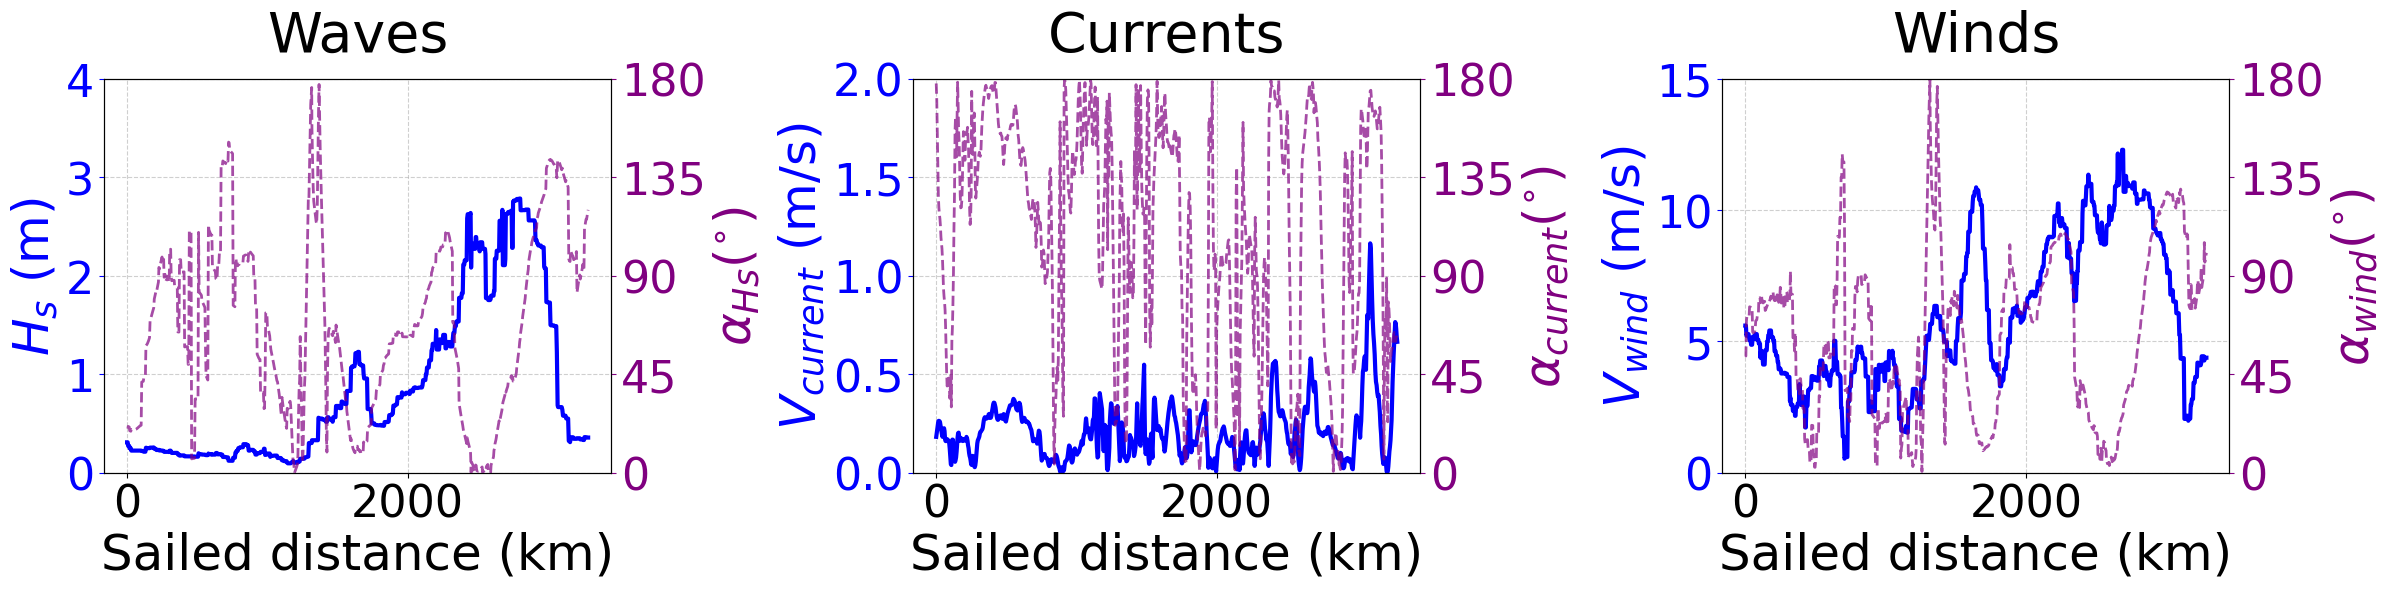

In [48]:
fig = plot_metocean_conditions(data_example)
fig.show()